# Chest X-ray Pneumonia Detection

# <b> <span style='color:dimgray'>Step 1 </span> <span style='color:crimson'>|</span> <span style='color:#53599A'>Import Modules</span></b>


In [29]:
import cv2
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.cm as cm
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import *
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.callbacks import EarlyStopping
import warnings 
warnings.filterwarnings("ignore")

# force CPU-only execution by hiding GPUs (prevents OOM on limited hardware)
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
print("CUDA_VISIBLE_DEVICES set to -1; using CPU only")
print("\n✅ Running on CPU only mode\n")
print("Available devices:", tf.config.list_logical_devices())

CUDA_VISIBLE_DEVICES set to -1; using CPU only

✅ Running on CPU only mode

Available devices: [LogicalDevice(name='/device:CPU:0', device_type='CPU')]


In [30]:

# --- dataset path configuration ---
# Try multiple paths for robustness
possible_paths = [
    os.path.join(os.getcwd(), "datasets"),           # Current directory
    os.path.join(os.getcwd(), "../datasets"),        # Parent directory
    os.path.join(os.path.dirname(os.getcwd()), "datasets"),  # Parent of current
]

datasets_root = None
for path in possible_paths:
    if os.path.isdir(path):
        datasets_root = path
        print(f"✅ Found datasets at: {path}")
        break

if datasets_root is None:
    print("❌ datasets directory not found at any of these locations:")
    for p in possible_paths:
        print(f"   - {p}")
    raise FileNotFoundError(
        "Could not locate 'datasets' folder. "
        "Please ensure it exists in the project root or run `python dataset.py` to download."
    )

candidates = [d for d in os.listdir(datasets_root) if "chest_xray" in d or "chest-xray" in d]

if not candidates:
    raise FileNotFoundError(
        f"Could not locate chest-xray-pneumonia dataset inside {datasets_root}. "
        "Please download it using dataset.py or check the folder name."
    )

base_path = os.path.join(datasets_root, candidates[0], "chest_xray")
train_dir = os.path.join(base_path, "train")
test_dir = os.path.join(base_path, "test")

print("dataset base path:", base_path)
print("train subfolders:", os.listdir(train_dir) if os.path.isdir(train_dir) else "<not found>")
print("test subfolders:", os.listdir(test_dir) if os.path.isdir(test_dir) else "<not found>")


✅ Found datasets at: /home/FedoroX/Documents/capstone_project/notebooks/../datasets
dataset base path: /home/FedoroX/Documents/capstone_project/notebooks/../datasets/chest_xray/chest_xray
train subfolders: ['.DS_Store', 'NORMAL', 'PNEUMONIA']
test subfolders: ['.DS_Store', 'NORMAL', 'PNEUMONIA']


# <b> <span style='color:dimgray'>Step 2 </span> <span style='color:crimson'>|</span> <span style='color:#53599A'>Data Directories</span></b>


In [31]:
def create_df(directory):
    filepaths = []
    labels = []
    folds = os.listdir(directory)
    for fold in folds:
        # Skip hidden/system files like .DS_Store, __MACOSX
        if fold.startswith('.'):
            continue
        f_path = os.path.join(directory, fold)
        # Only process directories
        if not os.path.isdir(f_path):
            continue
        imgs = os.listdir(f_path)
        for img in imgs:
            # Skip hidden files and system files
            if img.startswith('.'):
                continue
            img_path = os.path.join(f_path, img)
            filepaths.append(img_path)
            labels.append(fold)
    return pd.DataFrame({'filepath': filepaths, 'label': labels})

df_train = create_df(train_dir)
df_test = create_df(test_dir)


# <b> <span style='color:dimgray'>Step 3 </span> <span style='color:crimson'>|</span> <span style='color:#53599A'>Training, Validation & Test Dataset </span></b>


In [32]:
# training
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.1,
    subset='training',
    seed=123,
    image_size=(128, 128),
    batch_size=2)
# validation
validation_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.1,
    subset='validation',
    seed=123,
    image_size=(128, 128),
    batch_size=2)
# test
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    seed=123,
    image_size=(128, 128),
    batch_size=2)

Found 5216 files belonging to 2 classes.
Using 4695 files for training.
Found 5216 files belonging to 2 classes.
Using 521 files for validation.
Found 624 files belonging to 2 classes.


# <b> <span style='color:dimgray'>Step 4 </span> <span style='color:crimson'>|</span> <span style='color:#53599A'>Normalizing Pixel Valuess</span></b>


In [10]:
train_ds = train_ds.map(lambda x, y: (x / 255.0, y))
validation_ds = validation_ds.map(lambda x, y: (x / 255.0, y))
test_ds = test_ds.map(lambda x, y: (x / 255.0, y))

# <b> <span style='color:dimgray'>Step 5 </span> <span style='color:crimson'>|</span> <span style='color:#53599A'>Visual Count</span></b>


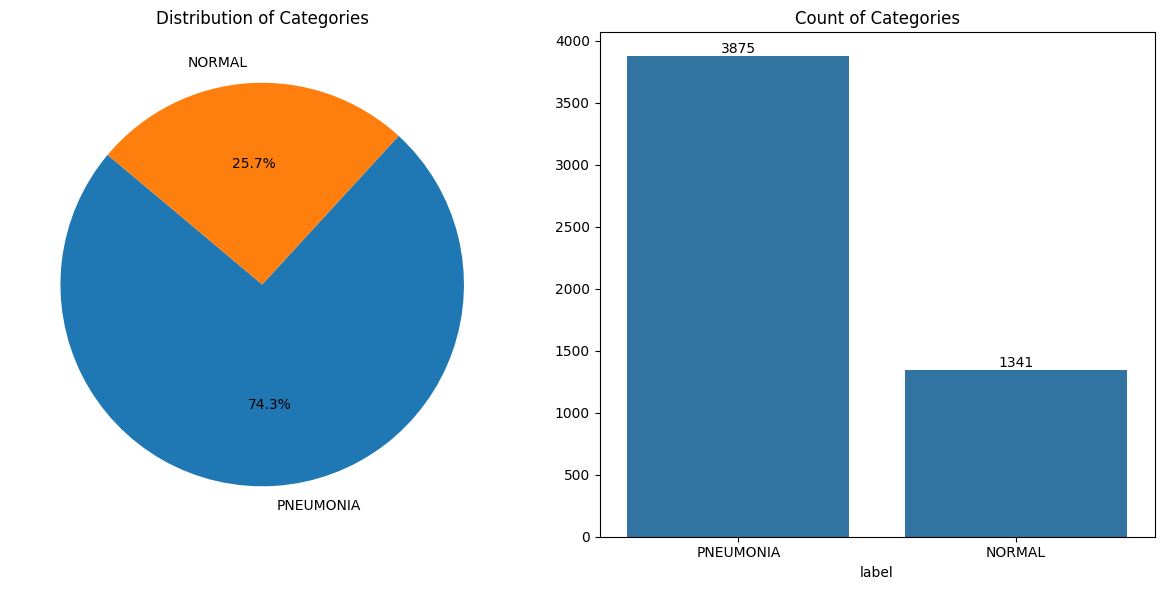

In [33]:
count = df_train['label'].value_counts()
fig, axs = plt.subplots(1, 2, figsize=(12, 6), facecolor='white')

axs[0].pie(count, labels=count.index, autopct='%1.1f%%', startangle=140)
axs[0].set_title('Distribution of Categories')

sns.barplot(x=count.index, y=count.values, ax=axs[1])
axs[1].set_title('Count of Categories')

for p in axs[1].patches:
    axs[1].text(p.get_x() + p.get_width()/2., 
                 p.get_height() + 3, 
                 str(int(p.get_height())),
                 ha='center', va='bottom')

plt.tight_layout()
plt.show()

# <b> <span style='color:dimgray'>Step 6 </span> <span style='color:crimson'>|</span> <span style='color:#53599A'>Train Images</span></b>

In [34]:
def visualize_images(path, num_images=4):
    image_filenames = [f for f in os.listdir(path) if not f.startswith('.')]
    num_images = min(num_images, len(image_filenames))
    fig, axes = plt.subplots(1, num_images, figsize=(15, 3),facecolor='white')

    for i, image_filename in enumerate(image_filenames[:num_images]):
        image_path = os.path.join(path, image_filename)
        image = mpimg.imread(image_path)
        
        axes[i].imshow(image)
        axes[i].axis('off') 
        axes[i].set_title(image_filename) 

    plt.tight_layout()
    plt.show()

# <b> <span style='color:dimgray'>Step 7 </span> <span style='color:crimson'>|</span> <span style='color:#53599A'>Normal Images</span></b>


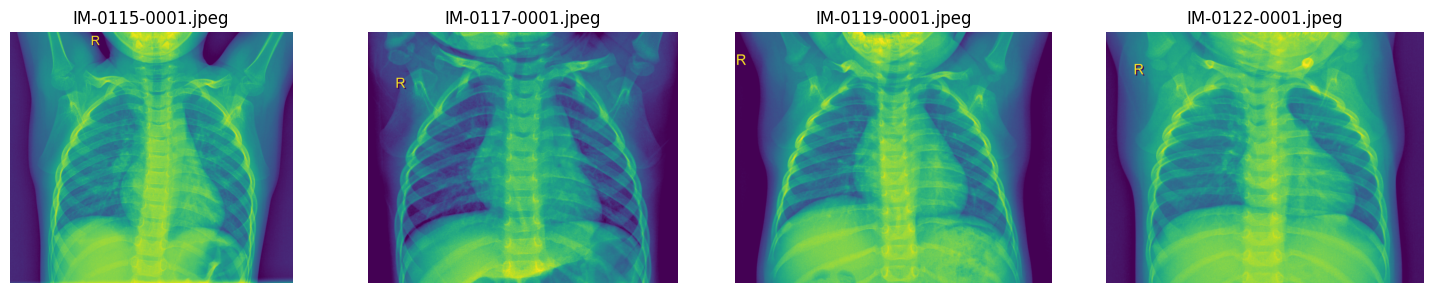

In [35]:
path_to_visualize = os.path.join(train_dir, "NORMAL")
visualize_images(path_to_visualize, num_images=4)


# <b> <span style='color:dimgray'>Step 8 </span> <span style='color:crimson'>|</span> <span style='color:#53599A'>Pneumonia Image</span></b>


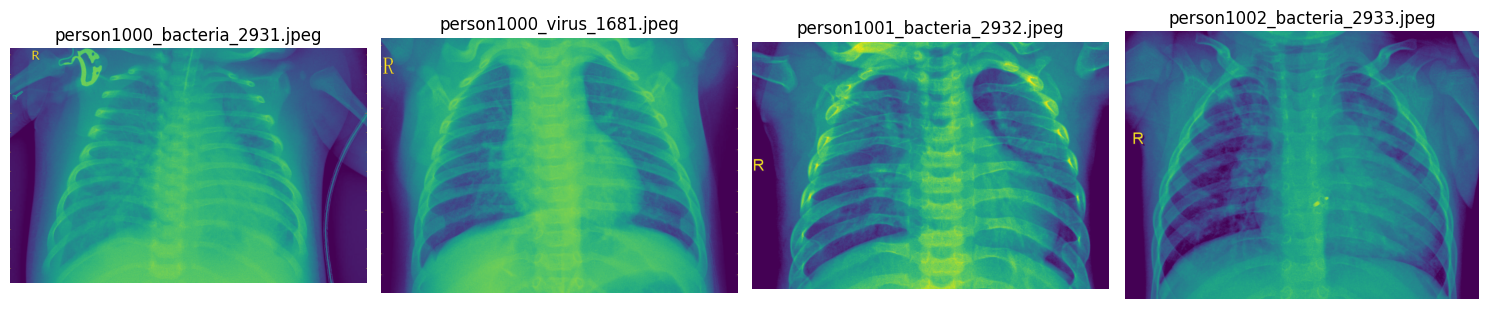

In [36]:
path_to_visualize = os.path.join(train_dir, "PNEUMONIA")
visualize_images(path_to_visualize, num_images=4)


# <b> <span style='color:dimgray'>Step 9 </span> <span style='color:crimson'>|</span> <span style='color:#53599A'>Building DenseNet121 Model</span></b>


In [37]:
base_model = DenseNet121(weights='imagenet', include_top=False, pooling='max', input_shape=(128, 128, 3))
base_model.trainable = False

# <b> <span style='color:dimgray'>Step 10 </span> <span style='color:crimson'>|</span> <span style='color:#53599A'>Sequential Model Architecture</span></b>


In [38]:
model = Sequential([
    base_model,
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adamax(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# <b> <span style='color:dimgray'>Step 11 </span> <span style='color:crimson'>|</span> <span style='color:#53599A'>Early Stopping</span></b>


In [39]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# <b> <span style='color:dimgray'>Step 12 </span> <span style='color:crimson'>|</span> <span style='color:#53599A'>Model Training</span></b>


In [40]:
history = model.fit(
    train_ds,
    epochs=20,
    validation_data=validation_ds,
    callbacks=[early_stopping])

Epoch 1/20
2348/2348 ━━━━━━━━━━━━━━━━━━━━ 85s 33ms/step - accuracy: 0.8017 - loss: 0.4482 - val_accuracy: 0.9328 - val_loss: 0.1836
Epoch 2/20
2348/2348 ━━━━━━━━━━━━━━━━━━━━ 74s 32ms/step - accuracy: 0.8462 - loss: 0.3549 - val_accuracy: 0.9424 - val_loss: 0.1847
Epoch 3/20
2348/2348 ━━━━━━━━━━━━━━━━━━━━ 75s 32ms/step - accuracy: 0.8588 - loss: 0.3325 - val_accuracy: 0.9463 - val_loss: 0.1798
Epoch 4/20
2348/2348 ━━━━━━━━━━━━━━━━━━━━ 75s 32ms/step - accuracy: 0.8679 - loss: 0.3050 - val_accuracy: 0.9405 - val_loss: 0.2024
Epoch 5/20
2348/2348 ━━━━━━━━━━━━━━━━━━━━ 75s 32ms/step - accuracy: 0.8603 - loss: 0.3180 - val_accuracy: 0.9443 - val_loss: 0.1916
Epoch 6/20
2348/2348 ━━━━━━━━━━━━━━━━━━━━ 75s 32ms/step - accuracy: 0.8803 - loss: 0.2872 - val_accuracy: 0.9501 - val_loss: 0.1989
Epoch 7/20
2348/2348 ━━━━━━━━━━━━━━━━━━━━ 76s 33ms/step - accuracy: 0.8801 - loss: 0.2857 - val_accuracy: 0.9443 - val_loss: 0.1899
Epoch 8/20
2348/2348 ━━━━━━━━━━━━━━━━━━━━ 75s 32ms/step - accuracy: 0.8905 -

# <b> <span style='color:dimgray'>Step 13 </span> <span style='color:crimson'>|</span> <span style='color:#53599A'>Training History</span></b>


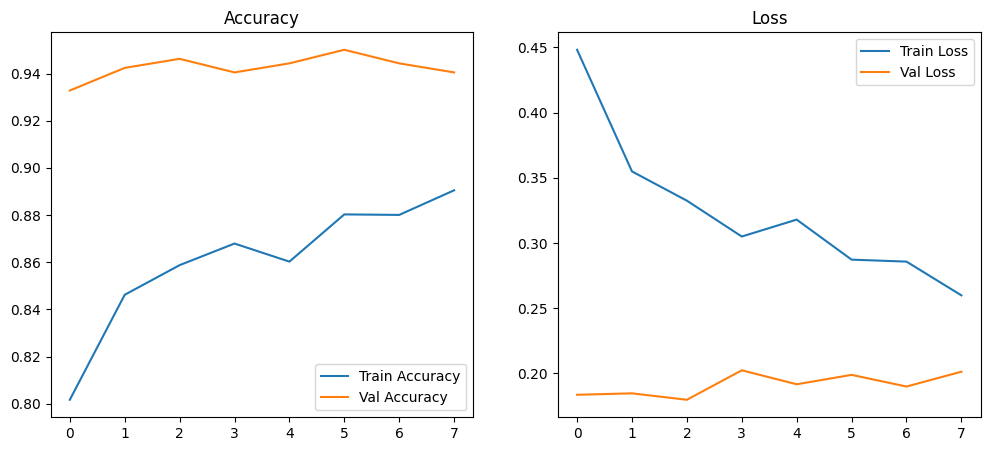

In [47]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

# <b> <span style='color:dimgray'>Step 14 </span> <span style='color:crimson'>|</span> <span style='color:#53599A'>Model Evaluation on Test Set</span></b>


In [48]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc*100:.2f}%")

312/312 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.8333 - loss: 0.6799
Test Accuracy: 83.33%


# <b> <span style='color:dimgray'>Step 15 </span> <span style='color:crimson'>|</span> <span style='color:#53599A'>Grad-CAM Heatmap</span></b>


In [51]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    base_m = model.layers[0]
    grad_model = tf.keras.models.Model([base_m.inputs], [base_m.get_layer(last_conv_layer_name).output, base_m.output])
    
    with tf.GradientTape() as tape:
        conv_outputs, base_output = grad_model(img_array)
        x = base_output
        for layer in model.layers[1:]: x = layer(x)
        class_channel = x[:, 0]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# <b> <span style='color:dimgray'>Step 16 </span> <span style='color:crimson'>|</span> <span style='color:#53599A'>Prediction with Highlights</span></b>


In [52]:
def predict_and_compare(img_path, model):
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_res = cv2.resize(img_rgb, (128, 128))
    img_array = np.expand_dims(img_res.astype(np.float32) / 255.0, axis=0)

    score = model.predict(img_array)[0][0]
    is_p = score > 0.5
    
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    ax[0].imshow(img_rgb); ax[0].set_title(f"Original\nPred: {'PNEUMONIA' if is_p else 'NORMAL'}"); ax[0].axis('off')

    if is_p:
        heatmap = make_gradcam_heatmap(img_array, model, 'relu')
        heatmap = cv2.resize(heatmap, (img_rgb.shape[1], img_rgb.shape[0]))
        jet_heatmap = cm.get_cmap("jet")(np.arange(256))[:, :3][np.uint8(255 * heatmap)]
        jet_heatmap = tf.keras.preprocessing.image.img_to_array(tf.keras.preprocessing.image.array_to_img(jet_heatmap).resize((img_rgb.shape[1], img_rgb.shape[0])))
        
        superimposed = jet_heatmap * 0.4 + img_rgb
        ax[1].imshow(tf.keras.preprocessing.image.array_to_img(superimposed))
        ax[1].set_title(f"Infected Areas (Score: {score*100:.1f}%)")
    else:
        ax[1].imshow(img_rgb); ax[1].set_title("No Infection Detected")
    ax[1].axis('off'); plt.show()

# <b> <span style='color:dimgray'>Step 17 </span> <span style='color:crimson'>|</span> <span style='color:#53599A'>Test Visualization</span></b>


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


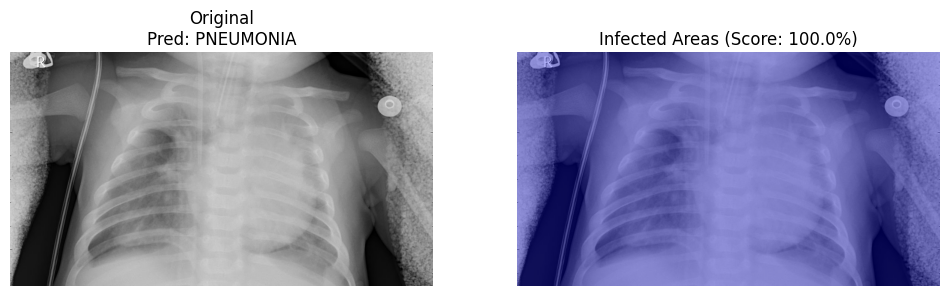

In [53]:
p_img = os.path.join(test_dir, 'PNEUMONIA', os.listdir(os.path.join(test_dir, 'PNEUMONIA'))[2])
predict_and_compare(p_img, model)

# <b> <span style='color:dimgray'>Step 18</span> <span style='color:crimson'>|</span> <span style='color:#53599A'>Saving the Model</span></b>


In [61]:
# ensure a models directory exists and save inside it (in project root, not notebooks/)
models_dir = os.path.join(os.path.dirname(os.getcwd()), "models")
os.makedirs(models_dir, exist_ok=True)

model_name = os.path.join(models_dir, 'pneumonia_detection_model.keras')
model.save(model_name)
print(f"✅ Model saved successfully as {model_name}")

# Verify the file was created
if os.path.exists(model_name):
    file_size = os.path.getsize(model_name) / (1024**2)  # Size in MB
    print(f"✅ File confirmed. Size: {file_size:.2f} MB")
else:
    print("❌ Error: File was not saved!")

✅ Model saved successfully as /home/FedoroX/Documents/capstone_project/models/pneumonia_detection_model.keras
✅ File confirmed. Size: 31.53 MB
